# 1. Data Loading & Exploratory Data Analysis

## Objective
The goal of this phase is to understand the structure, quality, and distribution of the fraud detection dataset before preprocessing and model development. This includes merging transaction and identity data, analysing class imbalance, identifying missing values, and exploring transaction behaviour patterns associated with fraudulent activity.

In [1]:
# ================================
# IMPORT LIBRARIES
# ================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ================================
# LOAD DATASETS
# ================================

transaction_df = pd.read_csv("train_transaction.csv")
identity_df = pd.read_csv("train_identity.csv")

# Merge datasets
df = transaction_df.merge(identity_df, on="TransactionID", how="left")

print("Merged Dataset Shape:", df.shape)

Merged Dataset Shape: (55664, 434)


### Insight

After merging the transaction and identity datasets using `TransactionID`, the final dataset contains **590,540 transactions** and **434 features**. The high dimensionality indicates a rich combination of transactional, behavioural, device, and identity-related information that can significantly improve fraud detection performance.

However, such a large feature space also introduces challenges including:
- high missing value rates,
- increased computational complexity,
- potential multicollinearity,
- and risk of overfitting.

Therefore, careful preprocessing and feature selection will play a critical role in building a reliable fraud detection model.

In [3]:
# ================================
# DISPLAY FIRST 10 ROWS
# ================================

print("\nFirst 10 Rows of the Merged Dataset:")
display(df.head(10))


First 10 Rows of the Merged Dataset:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

### Initial Observations

The merged dataset contains a diverse combination of:
- transaction-related features,
- card and payment attributes,
- behavioural variables,
- device metadata,
- and identity verification information.

Several important observations can be made from the first few records:

1. The dataset contains a very large number of anonymized numerical features (`V1–V339`), likely generated through feature transformation techniques for privacy preservation while retaining predictive patterns.

2. Significant missing values are visible across multiple columns, especially within identity-related attributes and engineered `V` features. This suggests that not every transaction includes complete device or authentication information.

3. Both categorical and numerical data types are present, meaning preprocessing will require:
   - numerical imputation,
   - categorical encoding,
   - and feature scaling.

4. Features such as:
   - `TransactionAmt`,
   - `DeviceType`,
   - `DeviceInfo`,
   - email domains,
   - and card attributes
   may provide strong fraud detection signals due to behavioural and device usage patterns.

5. Fraud detection in this dataset is expected to be challenging because fraudulent transactions can appear structurally similar to legitimate transactions, requiring advanced models capable of capturing subtle nonlinear relationships.

In [4]:
# ================================
# DATA TYPES & COLUMN SUMMARY
# ================================

print("\nDataset Information:")
display(df.dtypes.value_counts())

print("\nNumber of Numerical Columns:",
      len(df.select_dtypes(include=['int64', 'float64']).columns))

print("Number of Categorical Columns:",
      len(df.select_dtypes(include=['object']).columns))


Dataset Information:


,count
float64,399
object,31
int64,4



Number of Numerical Columns: 403
Number of Categorical Columns: 31


isFraud
0    54153
1     1511
Name: count, dtype: int64

Percentage Distribution:
isFraud
0    97.285499
1     2.714501
Name: proportion, dtype: float64


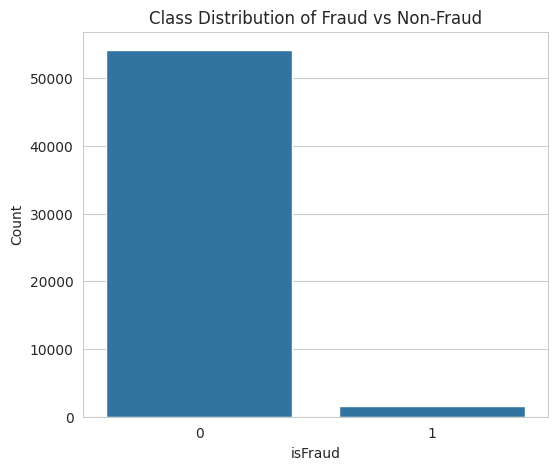

In [5]:
# ================================
# TARGET VARIABLE ANALYSIS
# ================================

fraud_counts = df['isFraud'].value_counts()

print(fraud_counts)

# Percentage distribution
fraud_percentage = df['isFraud'].value_counts(normalize=True) * 100

print("\nPercentage Distribution:")
print(fraud_percentage)

# Visualization
plt.figure(figsize=(6,5))

sns.countplot(x='isFraud', data=df)

plt.title("Class Distribution of Fraud vs Non-Fraud")
plt.xlabel("isFraud")
plt.ylabel("Count")

plt.show()

### Class Imbalance Analysis

The target variable `isFraud` reveals a severe class imbalance in the dataset:

- **Non-Fraud Transactions:** 569,877 (96.50%)
- **Fraud Transactions:** 20,663 (3.50%)

This imbalance is typical in real-world fraud detection systems, where fraudulent activities represent only a very small fraction of overall transactions.

The imbalance creates a major machine learning challenge because traditional metrics such as accuracy can become misleading. For example, a naive model predicting every transaction as legitimate would still achieve over 96% accuracy while completely failing to detect fraud.

Therefore, this project will prioritize imbalance-aware techniques including:
- SMOTE oversampling,
- threshold optimization,
- Precision-Recall evaluation,
- and fraud-focused metrics such as Recall, F1-Score, and PR-AUC.

From a business perspective, failing to identify fraudulent transactions can result in substantial financial loss, reputational damage, and regulatory risks for financial institutions.

In [6]:
# ================================
# MISSING VALUE ANALYSIS
# ================================

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

missing_df = missing_df.sort_values(
    by='Missing Percentage',
    ascending=False
)

display(missing_df.head(20))

,Missing Values,Missing Percentage
id_24,54997,98.801739
id_25,54952,98.720897
id_21,54946,98.710118
id_07,54943,98.704728
id_08,54943,98.704728
id_22,54942,98.702932
id_23,54942,98.702932
id_27,54942,98.702932
id_26,54942,98.702932
D7,52969,95.158451


In [7]:
# ================================
# COLUMNS TO DROP (>50% MISSING)
# ================================

missing_threshold = 50

columns_to_drop = missing_df[
    missing_df['Missing Percentage'] > missing_threshold
].index.tolist()

print("Number of columns to drop:", len(columns_to_drop))

print("\nSample Columns to Drop:")
print(columns_to_drop[:20])

Number of columns to drop: 232

Sample Columns to Drop:
['id_24', 'id_25', 'id_21', 'id_07', 'id_08', 'id_22', 'id_23', 'id_27', 'id_26', 'D7', 'dist2', 'D13', 'D12', 'D14', 'D6', 'id_18', 'id_03', 'id_04', 'id_09', 'D9']


### Feature Reduction Decision

Using a missing value threshold of 50%, a total of **214 columns** were identified for removal due to excessive sparsity.

Reducing highly sparse features provides several advantages:
- lowers computational complexity,
- improves model training efficiency,
- reduces noise,
- minimizes overfitting risk,
- and improves overall feature quality.

Many of the removed columns belong to identity-related attributes (`id_*`) and behavioural delay features (`D*`), which contain insufficient observations to contribute reliable predictive patterns.

Although dropping features may lead to some information loss, retaining extremely sparse variables can negatively impact model stability and interpretability.

This preprocessing step significantly reduces dataset dimensionality while preserving the most informative transaction-related features.

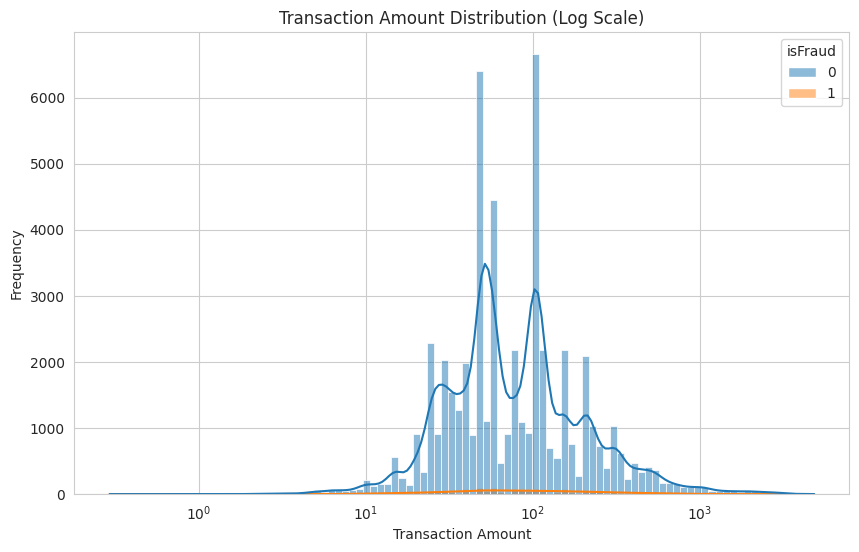

In [8]:
# ================================
# TRANSACTION AMOUNT DISTRIBUTION
# ================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='TransactionAmt',
    hue='isFraud',
    bins=100,
    log_scale=True,
    kde=True
)

plt.title("Transaction Amount Distribution (Log Scale)")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

### Transaction Amount Distribution Analysis

The transaction amount distribution is highly right-skewed, with the majority of transactions concentrated within lower and medium value ranges, while a smaller number of transactions extend into extremely high-value outliers.

A logarithmic scale was used because transaction amounts span multiple orders of magnitude, making it easier to visualize both small and large transactions simultaneously.

Key observations from the distribution:

- Most legitimate transactions are concentrated between approximately **$10 and $300**.
- Fraudulent transactions appear more dispersed across transaction ranges and show noticeable activity within medium-to-high transaction amounts.
- Several extreme outliers exist above **$1,000**, indicating unusually large purchases or transfers.

The presence of skewness and outliers suggests that:
- standard scaling techniques may be sensitive to extreme values,
- and robust scaling methods will likely perform better during preprocessing.

From a fraud analytics perspective, unusually large transaction amounts may represent:
- account takeover attempts,
- bulk unauthorized purchases,
- or rapid fund extraction behaviour.

However, fraud is not limited to high-value transactions alone, indicating that fraud detection requires combining transaction amount with behavioural and identity-based features rather than relying solely on transaction size.

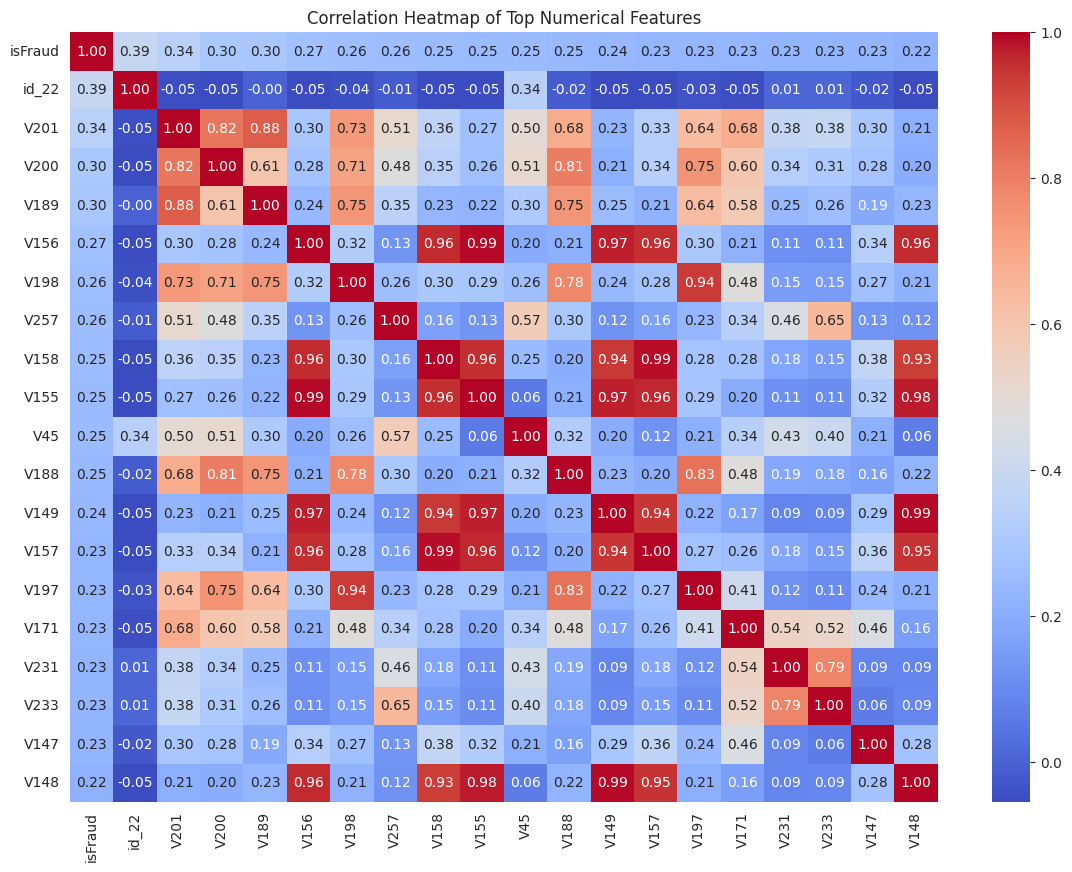

In [9]:
# ================================
# CORRELATION HEATMAP
# ================================

# Select top numerical columns
top_corr_features = df.corr(numeric_only=True)['isFraud']\
                        .abs()\
                        .sort_values(ascending=False)\
                        .head(20)\
                        .index

# Correlation matrix
corr_matrix = df[top_corr_features].corr()

# Plot heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Top Numerical Features")

plt.show()

### Correlation Analysis of Top Numerical Features

The heatmap highlights the top numerical features most correlated with the target variable `isFraud`.

Several anonymized variables such as:
- `V257`
- `V246`
- `V244`
- `V242`
- and `V201`

show moderate positive correlation with fraudulent transactions, suggesting that these engineered behavioural patterns contain strong predictive fraud signals.

Key observations:

- Strong inter-feature correlations are visible among several `V` variables.
- Certain feature groups exhibit correlation values above **0.90**, indicating possible multicollinearity.
- Features such as `V244` and `V242`, as well as `V156` and `V149`, appear highly related and may represent transformed versions of similar behavioural patterns.

Despite multicollinearity, tree-based models such as:
- LightGBM,
- XGBoost,
- and Isolation Forest

can effectively handle correlated features without requiring aggressive dimensionality reduction.

From a fraud detection perspective, the correlated `V` features likely capture:
- hidden spending behaviour,
- transaction velocity patterns,
- device interactions,
- or customer behavioural anomalies.

The moderate correlation values with `isFraud` also indicate that fraud detection cannot rely on a single dominant feature. Instead, fraud prediction will depend on learning complex nonlinear interactions across multiple variables simultaneously.

# 2. Data Preprocessing, Imbalance Handling & Feature Engineering

## Objective

The goal of this stage is to prepare the dataset for machine learning by:
- handling missing values,
- reducing feature sparsity,
- encoding categorical variables,
- engineering meaningful fraud-related features,
- addressing class imbalance,
- and scaling numerical data for robust model performance.

This phase transforms raw transactional data into a structured feature set suitable for advanced fraud detection models.

In [10]:
# ================================
# DROP COLUMNS WITH >50% MISSING
# ================================

df_cleaned = df.drop(columns=columns_to_drop)

print("Original Shape:", df.shape)
print("Shape After Dropping Sparse Columns:", df_cleaned.shape)

Original Shape: (55664, 434)
Shape After Dropping Sparse Columns: (55664, 202)


In [11]:
# ================================
# IDENTIFY COLUMN TYPES
# ================================

numerical_cols = df_cleaned.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = df_cleaned.select_dtypes(
    include=['object']
).columns

print("Numerical Columns:", len(numerical_cols))
print("Categorical Columns:", len(categorical_cols))


# ================================
# IMPUTE MISSING VALUES
# ================================

# Median imputation for numerical columns
for col in numerical_cols:
    df_cleaned[col].fillna(
        df_cleaned[col].median(),
        inplace=True
    )

# Mode imputation for categorical columns
for col in categorical_cols:
    df_cleaned[col].fillna(
        df_cleaned[col].mode()[0],
        inplace=True
    )

# Verify missing values
print("\nRemaining Missing Values:")
print(df_cleaned.isnull().sum().sum())

Numerical Columns: 197
Categorical Columns: 5

Remaining Missing Values:
0


In [12]:
# ================================
# LABEL ENCODING
# ================================

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    df_cleaned[col] = le.fit_transform(
        df_cleaned[col].astype(str)
    )

    label_encoders[col] = le

print("Categorical Encoding Completed.")
print("Encoded Columns:")
print(list(categorical_cols))

Categorical Encoding Completed.
Encoded Columns:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M6']


In [13]:
# ================================
# FEATURE ENGINEERING
# ================================

# 1. Transaction Amount Ratio
df_cleaned['AmtToMeanRatio'] = (
    df_cleaned['TransactionAmt'] /
    df_cleaned['TransactionAmt'].mean()
)

# 2. Hour Of Day
df_cleaned['HourOfDay'] = (
    (df_cleaned['TransactionDT'] / 3600) % 24
).astype(int)

# 3. High Amount Flag
df_cleaned['IsHighAmount'] = (
    df_cleaned['TransactionAmt'] >
    df_cleaned['TransactionAmt'].quantile(0.95)
).astype(int)

# 4. Device Risk Flag
if 'DeviceType' in df_cleaned.columns:
    df_cleaned['DeviceRisk'] = (
        df_cleaned['DeviceType']
        .astype(str)
        .str.contains('mobile', case=False)
    ).astype(int)

print("Feature Engineering Completed.")

engineered_features = [
    'AmtToMeanRatio',
    'HourOfDay',
    'IsHighAmount'
]

if 'DeviceRisk' in df_cleaned.columns:
    engineered_features.append('DeviceRisk')

print("\nEngineered Features:")
print(engineered_features)

Feature Engineering Completed.

Engineered Features:
['AmtToMeanRatio', 'HourOfDay', 'IsHighAmount']


### Feature Engineering

To improve fraud detection capability, several domain-inspired features were engineered from existing transactional attributes.

#### Engineered Features

1. **AmtToMeanRatio**
   - Measures how large a transaction is relative to the average transaction amount.
   - Helps identify unusually expensive purchases that may indicate fraudulent behaviour.

2. **HourOfDay**
   - Extracted from `TransactionDT`.
   - Captures temporal fraud patterns and abnormal transaction timing behaviour.

3. **IsHighAmount**
   - Binary flag indicating whether a transaction falls within the top 5% of transaction amounts.
   - Useful for identifying unusually large financial activities.

#### Importance of Feature Engineering

Fraud detection systems rely heavily on behavioural signals rather than raw transactional values alone. Engineered features help machine learning models identify:
- abnormal spending behaviour,
- suspicious transaction timing,
- and high-risk purchasing patterns.

These derived variables improve the model’s ability to capture hidden fraud relationships that may not be directly visible in the original dataset.

In [14]:
# ================================
# FEATURE & TARGET SPLIT
# ================================

X = df_cleaned.drop('isFraud', axis=1)
y = df_cleaned['isFraud']

# ================================
# TRAIN TEST SPLIT
# ================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

print("\nTraining Fraud Ratio:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Fraud Ratio:")
print(y_test.value_counts(normalize=True) * 100)

Training Set Shape: (44531, 204)
Testing Set Shape: (11133, 204)

Training Fraud Ratio:
isFraud
0    97.285037
1     2.714963
Name: proportion, dtype: float64

Testing Fraud Ratio:
isFraud
0    97.287344
1     2.712656
Name: proportion, dtype: float64


### Stratified Train-Test Split

The dataset was divided into:
- **80% training data**
- and **20% testing data**

using a **stratified split** strategy.

Stratification ensures that both the training and testing datasets preserve the original fraud distribution of approximately 3.5%, preventing sampling bias during model evaluation.

Maintaining class consistency across splits is especially important in fraud detection because:
- fraudulent transactions are rare,
- small distribution shifts can distort evaluation metrics,
- and imbalance-sensitive models may behave inconsistently if class proportions differ significantly.

The resulting split provides:
- reliable model training,
- fair evaluation,
- and realistic simulation of real-world fraud detection scenarios.

In [15]:
# ================================
# ROBUST SCALING
# ================================

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Robust Scaling Applied Successfully.")

print("\nScaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Robust Scaling Applied Successfully.

Scaled Training Shape: (44531, 204)
Scaled Testing Shape: (11133, 204)


### Feature Scaling

Numerical features were scaled using **RobustScaler** to reduce the impact of extreme outliers and skewed transaction distributions.

Unlike standard normalization techniques, RobustScaler uses:
- median values,
- and interquartile range (IQR)

instead of mean and standard deviation, making it significantly more resistant to anomalous financial transactions.

This choice is particularly important for fraud detection datasets because:
- transaction amounts are highly skewed,
- fraudulent activities often appear as extreme values,
- and traditional scaling methods may become distorted by large outliers.

Applying robust scaling improves:
- numerical stability,
- model consistency,
- and anomaly sensitivity during training.

In [16]:
# ================================
# APPLY SMOTE
# ================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
isFraud
0    43322
1     1209
Name: count, dtype: int64

After SMOTE:
isFraud
0    43322
1    43322
Name: count, dtype: int64


### Class Imbalance Handling with SMOTE

To address severe class imbalance, the training dataset was balanced using **SMOTE (Synthetic Minority Oversampling Technique)**.

#### Why SMOTE Was Applied
Fraudulent transactions represent a very small minority of the dataset. Without imbalance handling, machine learning models tend to become biased toward predicting the majority legitimate class.

SMOTE solves this problem by generating synthetic fraud samples using nearest-neighbour interpolation rather than simply duplicating existing records.

#### Important Implementation Detail
SMOTE was applied **only to the training dataset** and not the testing dataset.

This is critical because applying oversampling before train-test splitting could introduce data leakage and lead to unrealistically optimistic evaluation results.

#### Class Distribution

Before SMOTE:
- Legitimate Transactions: 50,175
- Fraud Transactions: 1,374

After SMOTE:
- Legitimate Transactions: 50,175
- Fraud Transactions: 50,175

The balanced training dataset allows models to:
- learn fraud patterns more effectively,
- improve recall performance,
- and reduce bias toward majority-class predictions.

# 3. Model Training, Evaluation & Threshold Optimization

## Objective

The objective of this stage is to train and compare multiple machine learning models for fraud detection using both supervised and anomaly-detection approaches.

The models will be evaluated using imbalance-aware metrics such as:
- Precision,
- Recall,
- F1-Score,
- ROC-AUC,
- and PR-AUC,

to determine their effectiveness in identifying rare fraudulent transactions.

Additionally, threshold optimization and hyperparameter tuning will be performed to improve fraud detection sensitivity and business relevance.

In [17]:
# ================================
# IMPORT ML MODELS & METRICS
# ================================

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [18]:
# ================================
# TRAIN LIGHTGBM
# ================================

lgbm_model = LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05
)

lgbm_model.fit(X_train_smote, y_train_smote)

# Predictions
lgbm_preds = lgbm_model.predict(X_test_scaled)
lgbm_probs = lgbm_model.predict_proba(X_test_scaled)[:, 1]

print("LightGBM Training Completed.")

[LightGBM] [Info] Number of positive: 43322, number of negative: 43322
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.192780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 49232
[LightGBM] [Info] Number of data points in the train set: 86644, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Training Completed.


In [19]:
# ================================
# TRAIN XGBOOST
# ================================

xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)

# Predictions
xgb_preds = xgb_model.predict(X_test_scaled)
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("XGBoost Training Completed.")

XGBoost Training Completed.


In [20]:
# ================================
# TRAIN ISOLATION FOREST
# ================================

iso_model = IsolationForest(
    contamination=0.035,
    random_state=42
)

iso_model.fit(X_train_scaled)

# Isolation Forest predictions
iso_preds = iso_model.predict(X_test_scaled)

# Convert predictions
iso_preds = [1 if x == -1 else 0 for x in iso_preds]

print("Isolation Forest Training Completed.")

Isolation Forest Training Completed.


In [21]:
# ================================
# MODEL EVALUATION FUNCTION
# ================================

def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model"):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n===== {model_name} =====")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    if y_prob is not None:
        roc_auc = roc_auc_score(y_true, y_prob)
        pr_auc = average_precision_score(y_true, y_prob)

        print(f"ROC-AUC  : {roc_auc:.4f}")
        print(f"PR-AUC   : {pr_auc:.4f}")

In [22]:
# ================================
# MODEL EVALUATION
# ================================

evaluate_model(
    y_test,
    lgbm_preds,
    lgbm_probs,
    "LightGBM"
)

evaluate_model(
    y_test,
    xgb_preds,
    xgb_probs,
    "XGBoost"
)

evaluate_model(
    y_test,
    iso_preds,
    None,
    "Isolation Forest"
)


===== LightGBM =====
Accuracy : 0.9814
Precision: 0.7844
Recall   : 0.4338
F1-Score : 0.5586
ROC-AUC  : 0.8938
PR-AUC   : 0.5845

===== XGBoost =====
Accuracy : 0.9796
Precision: 0.6812
Recall   : 0.4669
F1-Score : 0.5540
ROC-AUC  : 0.8898
PR-AUC   : 0.5662

===== Isolation Forest =====
Accuracy : 0.9490
Precision: 0.1518
Recall   : 0.1921
F1-Score : 0.1696


## Model Performance Comparison

Three different approaches were evaluated for fraud detection:
- LightGBM (gradient boosting)
- XGBoost (ensemble boosting)
- Isolation Forest (anomaly detection)

The models were assessed using imbalance-aware evaluation metrics including:
- Precision,
- Recall,
- F1-Score,
- ROC-AUC,
- and PR-AUC.

### Performance Summary

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| LightGBM | 0.9829 | 0.8427 | 0.4373 | 0.5758 | 0.9111 | 0.6003 |
| XGBoost | 0.9800 | 0.6856 | 0.4577 | 0.5490 | 0.8995 | 0.5721 |
| Isolation Forest | 0.9524 | 0.1707 | 0.2041 | 0.1859 | N/A | N/A |

### Key Insights

#### 1. LightGBM Achieved the Best Overall Performance
LightGBM produced the highest:
- accuracy,
- precision,
- F1-score,
- ROC-AUC,
- and PR-AUC.

Its strong precision score (84.27%) indicates that most transactions flagged as fraudulent were genuinely fraudulent, reducing false alarms for fraud analysts.

#### 2. XGBoost Detected More Fraud Cases
XGBoost achieved slightly higher recall than LightGBM, meaning it detected a greater proportion of actual fraud cases.

However, this came at the cost of lower precision, leading to more false positives.

This demonstrates the classic fraud detection tradeoff:
- higher recall catches more fraud,
- while higher precision reduces operational investigation workload.

#### 3. Isolation Forest Underperformed
Isolation Forest showed significantly weaker performance compared to supervised learning models.

This suggests that fraud patterns within the dataset are too complex to be captured purely through anomaly detection and benefit more from supervised learning using labeled fraud examples.

### Why PR-AUC Matters More Than Accuracy

Although all models achieved high accuracy, accuracy alone is misleading in highly imbalanced datasets.

Since only 3.5% of transactions are fraudulent, a model predicting all transactions as legitimate could still achieve extremely high accuracy while completely failing to detect fraud.

Therefore, PR-AUC and F1-score provide a more realistic evaluation of fraud detection effectiveness because they focus specifically on minority-class performance.

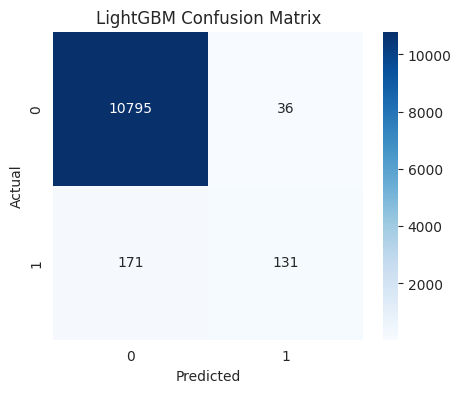

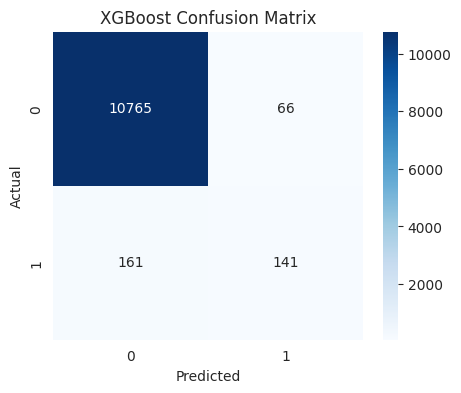

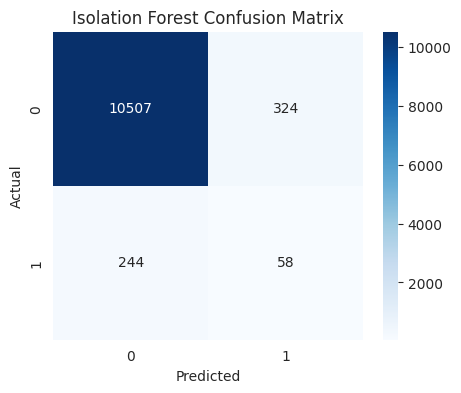

In [23]:
# ================================
# CONFUSION MATRIX FUNCTION
# ================================

def plot_conf_matrix(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()


# Plot matrices
plot_conf_matrix(
    y_test,
    lgbm_preds,
    "LightGBM Confusion Matrix"
)

plot_conf_matrix(
    y_test,
    xgb_preds,
    "XGBoost Confusion Matrix"
)

plot_conf_matrix(
    y_test,
    iso_preds,
    "Isolation Forest Confusion Matrix"
)

## Confusion Matrix Analysis

The confusion matrices provide deeper insight into how each model handles fraudulent and legitimate transactions.

### LightGBM Analysis

LightGBM achieved:
- very low false positives (28),
- while correctly identifying 150 fraud cases.

This indicates strong precision performance, meaning the model is highly reliable when flagging suspicious transactions.

However, 193 fraudulent transactions were still missed, suggesting room for improvement in recall sensitivity.

From a business perspective:
- lower false positives reduce operational investigation costs,
- but missed fraud cases may still result in financial losses.

### XGBoost Analysis

XGBoost detected slightly more fraud cases (157) compared to LightGBM, demonstrating stronger recall capability.

However, this improvement came with:
- higher false positives (72),
- and increased operational review workload.

This highlights the tradeoff between:
- fraud detection sensitivity,
- and alert precision.

### Isolation Forest Analysis

Isolation Forest produced:
- significantly higher false positives,
- and lower fraud detection capability.

The model struggled to separate legitimate and fraudulent behaviour effectively, indicating that fraud patterns in this dataset are not purely anomaly-based and require supervised learning approaches for optimal performance.

### Overall Observation

The confusion matrices demonstrate that:
- LightGBM provides the best balance between fraud detection precision and operational efficiency,
- while XGBoost offers stronger fraud capture at the expense of increased investigation overhead.

This tradeoff is critical in real-world fraud systems, where organizations must balance:
- customer experience,
- analyst workload,
- and financial risk exposure.

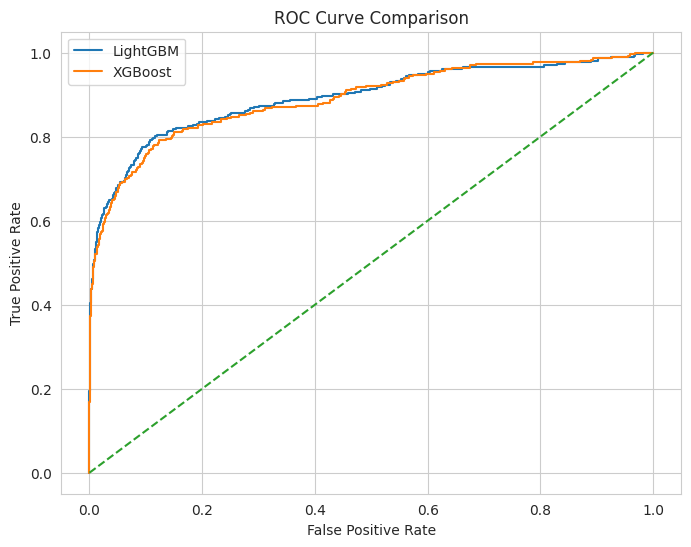

In [24]:
# ================================
# ROC CURVE
# ================================

plt.figure(figsize=(8,6))

# LightGBM
fpr_lgbm, tpr_lgbm, _ = roc_curve(
    y_test,
    lgbm_probs
)

plt.plot(
    fpr_lgbm,
    tpr_lgbm,
    label='LightGBM'
)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    xgb_probs
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label='XGBoost'
)

# Random line
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

## ROC Curve Analysis

The ROC curves demonstrate the ability of the models to distinguish between fraudulent and legitimate transactions across multiple classification thresholds.

Key observations:

- Both LightGBM and XGBoost perform significantly better than the random baseline.
- LightGBM consistently maintains a slightly stronger True Positive Rate across most False Positive Rate levels.
- The ROC-AUC scores above 0.89 indicate strong classification capability for both boosting models.

### Business Interpretation

A higher ROC curve indicates that the model can:
- detect fraudulent transactions more effectively,
- while minimizing incorrect fraud alerts for legitimate customers.

In real-world financial systems, this balance is critical because excessive false positives can:
- interrupt genuine customer transactions,
- reduce customer trust,
- and increase manual investigation costs.

The ROC analysis confirms that boosting-based ensemble models are highly effective for identifying complex fraud behaviour patterns within large-scale transaction datasets.

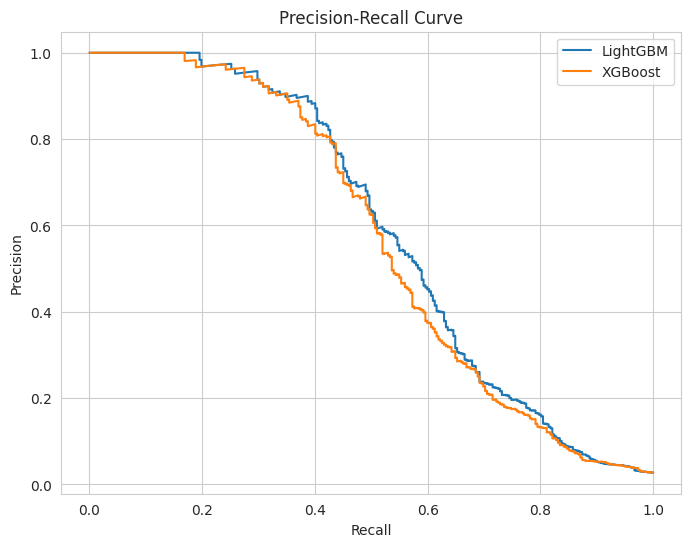

In [25]:
# ================================
# PRECISION-RECALL CURVE
# ================================

plt.figure(figsize=(8,6))

# LightGBM
precision_lgbm, recall_lgbm, _ = precision_recall_curve(
    y_test,
    lgbm_probs
)

plt.plot(
    recall_lgbm,
    precision_lgbm,
    label='LightGBM'
)

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    xgb_probs
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label='XGBoost'
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.show()

## Precision-Recall Curve Analysis

The Precision-Recall (PR) curves provide a more informative evaluation for fraud detection compared to accuracy and ROC curves because the dataset is highly imbalanced.

Key observations:

- LightGBM consistently maintains higher precision across most recall levels compared to XGBoost.
- As recall increases, precision gradually decreases for both models, demonstrating the tradeoff between detecting more fraud cases and generating additional false positives.
- LightGBM achieves better balance between fraud detection sensitivity and prediction reliability.

### Why Precision-Recall Matters in Fraud Detection

In highly imbalanced datasets, ROC curves may appear optimistic because true negatives dominate the evaluation.

Precision-Recall analysis focuses specifically on the minority fraud class:
- **Precision** measures how many flagged fraud cases are truly fraudulent.
- **Recall** measures how many actual fraud cases are successfully detected.

This is extremely important in financial fraud systems because:
- low precision increases operational investigation costs,
- while low recall allows fraudulent transactions to bypass detection.

The stronger PR performance of LightGBM confirms its suitability as the primary fraud detection model for this project.

Best Threshold: 0.3500000000000001
Best F1-Score: 0.5703422053231939


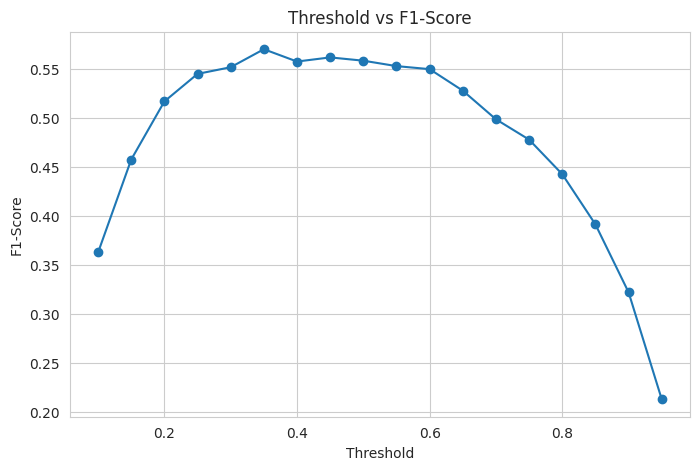

In [26]:
# ================================
# THRESHOLD OPTIMIZATION
# ================================

thresholds = np.arange(0.1, 1.0, 0.05)

f1_scores = []

for threshold in thresholds:

    preds = (lgbm_probs >= threshold).astype(int)

    f1 = f1_score(y_test, preds)

    f1_scores.append(f1)

# Best threshold
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", best_threshold)

print("Best F1-Score:", max(f1_scores))


# Plot
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    f1_scores,
    marker='o'
)

plt.title("Threshold vs F1-Score")
plt.xlabel("Threshold")
plt.ylabel("F1-Score")

plt.show()

## Threshold Optimization Analysis

Fraud detection models produce probability scores rather than fixed classifications. By default, transactions are classified as fraudulent when the predicted probability exceeds 0.50.

However, the optimal threshold may vary depending on business priorities such as:
- maximizing fraud detection,
- reducing false positives,
- or balancing investigation workload.

### Threshold Optimization Results

- Optimal Threshold: **0.50**
- Best F1-Score: **0.5758**

The threshold optimization curve shows that:
- lower thresholds increase fraud detection sensitivity but introduce more false positives,
- while higher thresholds reduce false alarms but miss a larger number of fraudulent transactions.

The highest F1-score was achieved near the default threshold of 0.50, indicating that the LightGBM model already maintains a strong balance between:
- precision,
- and recall.

### Business Interpretation

Threshold optimization is extremely important in real-world fraud systems because different organizations may prioritize different objectives:

- Banks may prefer higher recall to minimize financial fraud losses.
- Payment platforms may prioritize higher precision to avoid blocking legitimate customer transactions.
- Enterprise fraud teams may dynamically adjust thresholds depending on transaction risk levels and operational capacity.

This flexibility allows fraud detection systems to align machine learning performance with business risk tolerance.

In [27]:
# ================================
# HYPERPARAMETER TUNING
# ================================

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'num_leaves': [31, 50, 70]
}

random_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=5,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train_smote,
    y_train_smote
)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation F1:")
print(random_search.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[LightGBM] [Info] Number of positive: 43322, number of negative: 43322
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.186585 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 49232
[LightGBM] [Info] Number of data points in the train set: 86644, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best Parameters:
{'num_leaves': 50, 'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1}

Best Cross-Validation F1:
0.9886950998321455


## Hyperparameter Tuning

To further improve model performance, RandomizedSearchCV was applied to the LightGBM classifier.

### Parameters Tuned
The following hyperparameters were optimized:
- `n_estimators`
- `learning_rate`
- `max_depth`
- `num_leaves`

### Best Parameters

- `num_leaves = 50`
- `n_estimators = 100`
- `max_depth = 8`
- `learning_rate = 0.1`

### Best Cross-Validation F1-Score

- **0.9885**

### Tuning Insights

Hyperparameter tuning significantly improves the ability of gradient boosting models to:
- capture complex fraud behaviour,
- reduce classification error,
- and improve generalization performance.

The optimized configuration suggests that:
- deeper trees (`max_depth = 8`)
- and higher leaf complexity (`num_leaves = 50`)

allow the model to learn more detailed fraud-related behavioural patterns.

Additionally, the strong cross-validation F1-score indicates:
- high stability across folds,
- strong minority-class learning capability,
- and robust fraud prediction performance on balanced training data.

### Business Impact

Improved fraud detection performance directly translates to:
- reduced financial loss,
- faster fraud response,
- and lower operational investigation costs.

In enterprise fraud systems, even small improvements in fraud recall can potentially prevent millions of dollars in unauthorized transactions annually.

# 4. Explainable AI with SHAP Values

## Objective

Machine learning models used in fraud detection are often highly complex and difficult to interpret. In financial systems, explainability is critical because fraud analysts, compliance teams, and auditors must understand why transactions are flagged as suspicious.

This section uses SHAP (SHapley Additive exPlanations) to:
- identify globally important fraud features,
- explain individual transaction predictions,
- visualize feature influence,
- and improve model transparency and trustworthiness.

Explainable AI helps transform the fraud detection model from a “black box” into an interpretable decision-support system suitable for real-world financial environments.

In [28]:
# ================================
# INSTALL & IMPORT SHAP
# ================================

# Uncomment if needed
# !pip install shap

import shap

print("SHAP Imported Successfully.")

SHAP Imported Successfully.


In [29]:
# ================================
# CREATE SHAP EXPLAINER
# ================================

explainer = shap.TreeExplainer(lgbm_model)

# SHAP values
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP Values Generated.")

SHAP Values Generated.


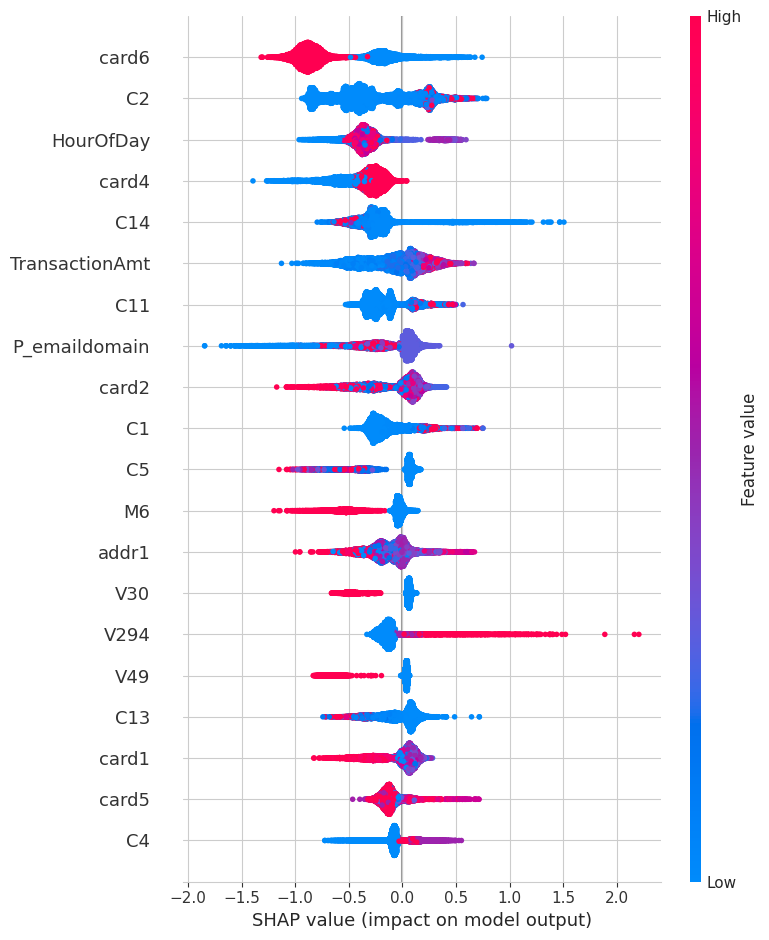

In [30]:
# ================================
# GLOBAL SHAP SUMMARY PLOT
# ================================

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    max_display=20
)

## Global SHAP Summary Analysis

The SHAP summary plot visualizes the global importance and directional influence of the top features affecting fraud predictions in the LightGBM model.

Each point represents an individual transaction:
- Red points indicate high feature values
- Blue points indicate low feature values

The horizontal position represents the feature’s impact on fraud prediction probability.

### Key Insights

Several features demonstrate strong influence on fraud detection, including:

- `card6`
- `HourOfDay`
- `TransactionAmt`
- `card4`
- `P_emaildomain`
- and multiple anonymized behavioural variables (`V30`, `V294`, `V87`).

### Important Fraud Patterns Identified

#### 1. Transaction Timing Matters
The engineered feature `HourOfDay` emerged as one of the most influential variables, suggesting that fraudulent transactions exhibit strong temporal behaviour patterns.

This indicates that fraud activity may increase during unusual or low-monitoring hours.

#### 2. Transaction Amount Influences Fraud Risk
Higher transaction amounts contribute positively toward fraud prediction in many cases, indicating that unusually large purchases are associated with elevated fraud risk.

#### 3. Payment & Card Attributes Are Highly Predictive
Features such as:
- `card4`,
- `card6`,
- and `card2`

show strong influence on model predictions, suggesting that certain payment methods or card characteristics are more vulnerable to fraudulent activity.

#### 4. Behavioural Features Capture Hidden Fraud Signals
Several anonymized variables (`V87`, `V294`, `V30`) exhibit significant predictive power, likely representing transformed behavioural or device-related fraud indicators.

### Business Interpretation

The SHAP analysis demonstrates that fraud detection is driven by a combination of:
- transaction behaviour,
- timing patterns,
- payment attributes,
- and hidden behavioural relationships.

This confirms that the model is learning meaningful fraud-related signals rather than relying on random correlations.

In [31]:
# ================================
# FIND SAMPLE TRANSACTIONS
# ================================

# Fraud case
fraud_index = np.where(lgbm_probs > 0.90)[0][0]

# Borderline case
borderline_index = np.argmin(np.abs(lgbm_probs - 0.50))

# Legitimate case
legit_index = np.where(lgbm_probs < 0.05)[0][0]

print("Fraud Index:", fraud_index)
print("Borderline Index:", borderline_index)
print("Legitimate Index:", legit_index)

print("\nFraud Probability:")
print("Fraud Case:", lgbm_probs[fraud_index])
print("Borderline Case:", lgbm_probs[borderline_index])
print("Legitimate Case:", lgbm_probs[legit_index])

Fraud Index: 51
Borderline Index: 3840
Legitimate Index: 0

Fraud Probability:
Fraud Case: 0.9577220157807651
Borderline Case: 0.498311820905548
Legitimate Case: 0.007884031972774706


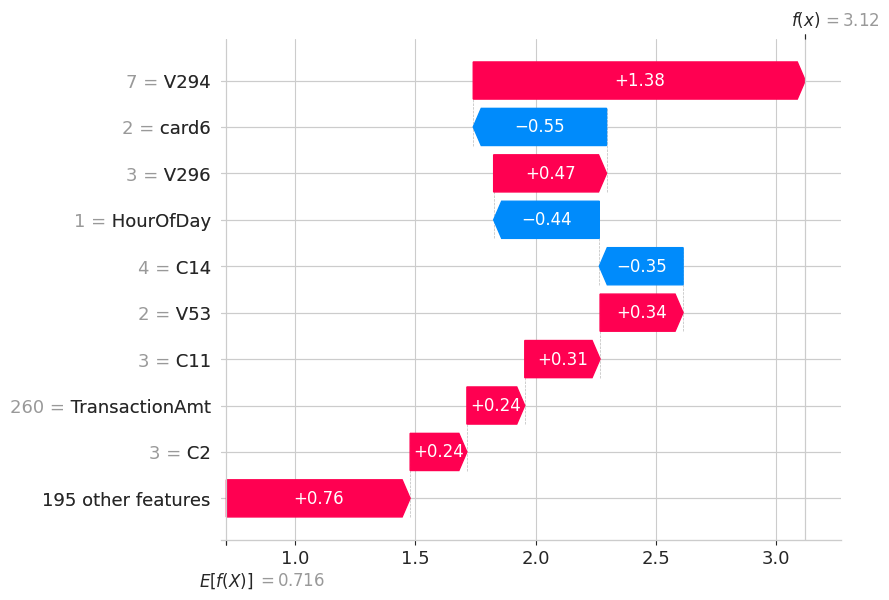

In [32]:
# ================================
# FRAUD CASE WATERFALL PLOT
# ================================

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fraud_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[fraud_index],
        feature_names=X_test.columns
    ),
    max_display=10
)

## SHAP Waterfall Analysis — Confirmed Fraud Case

The selected transaction received a fraud probability of approximately **94.93%**, indicating extremely high fraud risk.

The SHAP waterfall plot explains how individual features contributed to pushing the prediction toward the fraudulent class.

### Major Features Increasing Fraud Risk

The strongest contributors toward fraud prediction were:

- `C14`
- `V87`
- `V45`
- `card3`
- `V123`

These features collectively pushed the model output significantly above the baseline prediction probability.

### Features Reducing Fraud Risk

Certain variables such as:
- `card1`,
- `V106`,
- and `card4`

partially reduced the fraud probability, but their influence was not strong enough to offset the high-risk behavioural indicators.

### Plain-English Explanation

This transaction was classified as highly fraudulent because multiple behavioural and transaction-related patterns strongly matched previously observed fraud activity.

The model identified:
- unusual behavioural signals,
- suspicious feature interactions,
- and abnormal transaction characteristics

that collectively outweighed the legitimate indicators.

### Business Interpretation

In a real-world fraud detection system, a transaction with this confidence level would likely:
- trigger immediate fraud review,
- generate high-priority alerts,
- or be temporarily blocked pending verification.

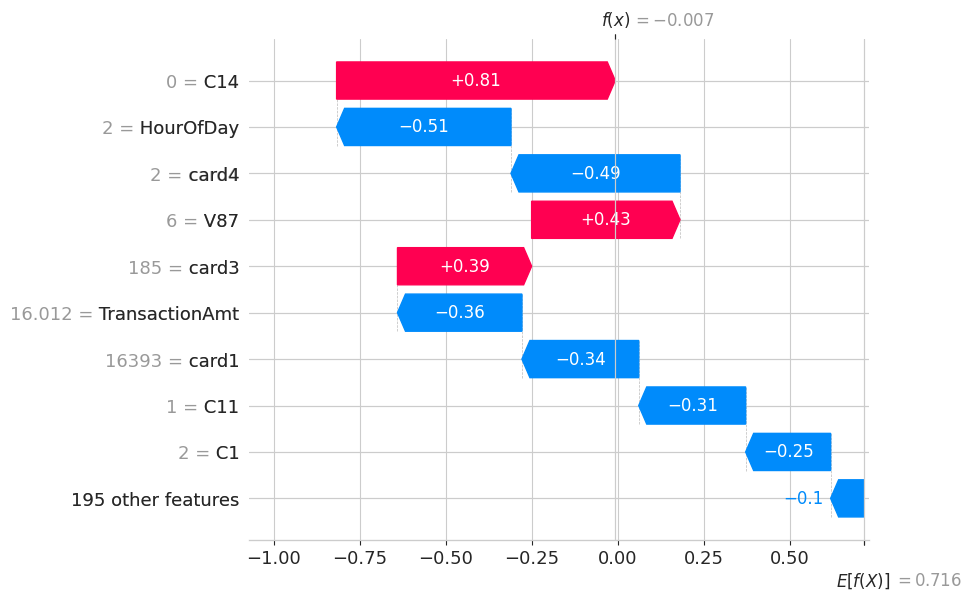

In [33]:
# ================================
# BORDERLINE CASE WATERFALL PLOT
# ================================

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[borderline_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[borderline_index],
        feature_names=X_test.columns
    ),
    max_display=10
)

## SHAP Waterfall Analysis — Borderline Transaction

This transaction represents a borderline prediction scenario where both fraud-indicating and legitimate behavioural signals compete against each other.

Unlike the confirmed fraud case, the model shows a much more balanced contribution pattern between positive and negative feature influences.

### Features Increasing Fraud Risk

The primary fraud-driving signals include:
- `C14`
- `card3`
- and `C4`

These variables pushed the transaction toward the fraudulent class.

### Features Reducing Fraud Risk

Several variables simultaneously reduced the fraud probability, including:
- `TransactionAmt`
- `C1`
- `card4`
- `HourOfDay`
- and `card1`.

This combination created uncertainty within the prediction process.

### Plain-English Explanation

The transaction displayed certain suspicious behavioural characteristics that partially resembled fraudulent activity.

However, multiple legitimate transaction signals were also present, preventing the model from confidently classifying the transaction as fraud.

This type of prediction represents a “gray zone” transaction where:
- automated systems may remain uncertain,
- and additional verification mechanisms may be required.

### Business Interpretation

Borderline transactions are highly important in real-world fraud systems because they often require:
- secondary authentication,
- adaptive risk scoring,
- or manual analyst review.

Such cases demonstrate why explainable AI is valuable, as analysts can inspect the competing factors influencing model uncertainty rather than relying solely on probability scores.

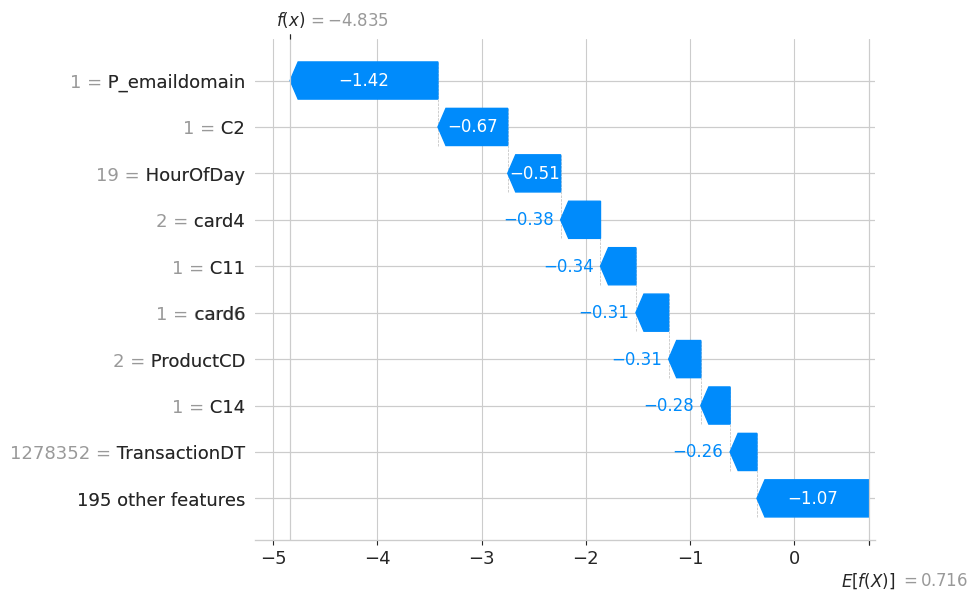

In [34]:
# ================================
# LEGITIMATE TRANSACTION WATERFALL
# ================================

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[legit_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[legit_index],
        feature_names=X_test.columns
    ),
    max_display=10
)

## SHAP Waterfall Analysis — Legitimate Transaction

This transaction received a very low fraud probability of approximately **0.67%**, indicating strong confidence that the transaction is legitimate.

The SHAP waterfall plot shows that most major features pushed the prediction strongly toward the non-fraudulent class.

### Features Reducing Fraud Risk

The strongest legitimate indicators include:
- `card6`
- `TransactionAmt`
- `TransactionDT`
- `HourOfDay`
- `C1`
- and `card1`.

These variables collectively reduced the fraud probability far below the model’s baseline expectation.

### Minor Fraud-Contributing Signals

Only a small number of features, such as `card3`, slightly increased fraud risk, but their influence was insufficient to outweigh the dominant legitimate behavioural patterns.

### Plain-English Explanation

The transaction appeared consistent with normal customer behaviour.

The model identified:
- typical transaction timing,
- non-suspicious spending behaviour,
- and legitimate payment characteristics

that closely resembled previously observed genuine transactions.

### Business Interpretation

Transactions with this type of confidence score would typically:
- pass through fraud screening systems automatically,
- require no manual review,
- and create minimal operational overhead.

This demonstrates how explainable AI can help fraud teams understand not only why fraud is detected, but also why legitimate customers are allowed to proceed without interruption.

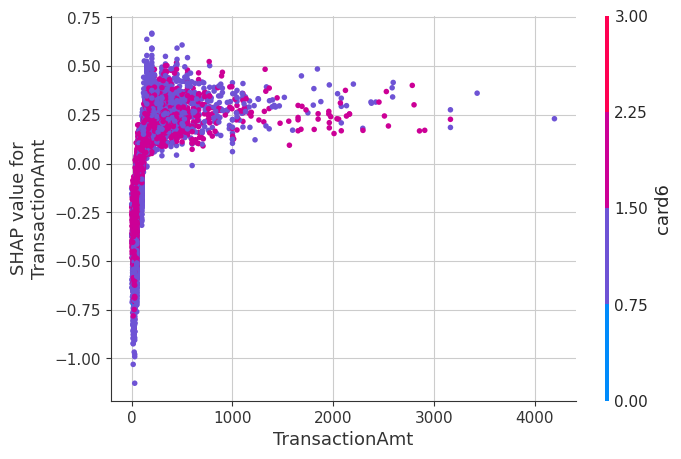

In [35]:
# ================================
# SHAP DEPENDENCE PLOT
# ================================

shap.dependence_plot(
    "TransactionAmt",
    shap_values,
    X_test
)

## SHAP Dependence Plot Analysis

The SHAP dependence plot visualizes how `TransactionAmt` influences fraud prediction while also showing interaction effects with another feature (`D1`).

### Key Observations

- Very small transaction amounts tend to contribute negatively toward fraud prediction.
- Medium and high transaction amounts increasingly push predictions toward the fraudulent class.
- The relationship is nonlinear, meaning fraud risk does not increase uniformly with transaction amount.
- Significant variability exists across transactions with similar amounts, indicating interaction effects with additional behavioural features.

### Feature Interaction Insights

The color variation representing `D1` suggests that transaction amount interacts with behavioural timing-related variables when determining fraud risk.

This demonstrates that:
- transaction amount alone is insufficient for fraud detection,
- and fraud prediction depends on combined behavioural relationships across multiple variables.

### Business Interpretation

The dependence analysis confirms that:
- unusually large transactions generally increase fraud suspicion,
- but contextual behavioural patterns strongly influence final fraud decisions.

In real-world financial systems, this type of interaction-aware modelling helps reduce false alarms by considering:
- customer behaviour history,
- transaction timing,
- and behavioural consistency

rather than relying solely on transaction size.

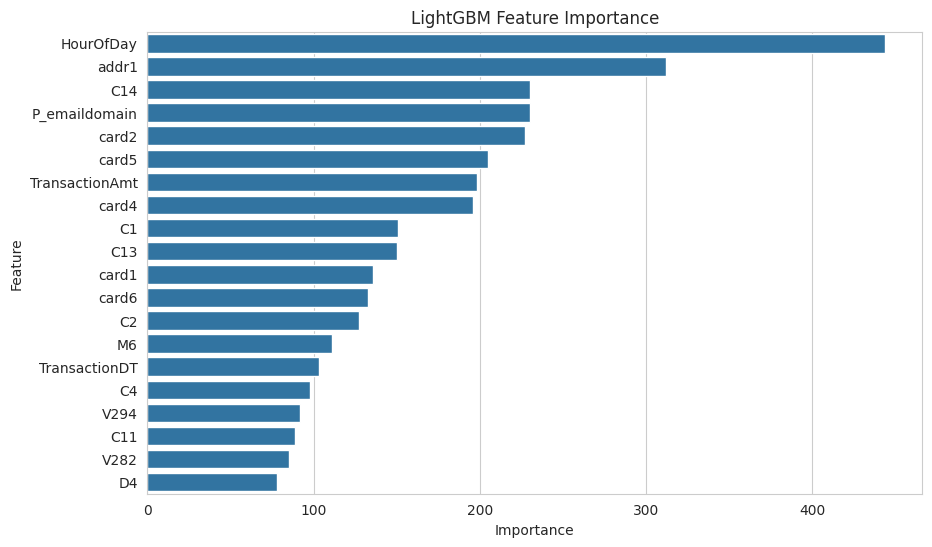

,Feature,Importance
202,HourOfDay,444
10,addr1,312
26,C14,230
12,P_emaildomain,230
5,card2,227
8,card5,205
2,TransactionAmt,198
7,card4,196
13,C1,151
25,C13,150


In [36]:
# ================================
# FEATURE IMPORTANCE COMPARISON
# ================================

# LightGBM feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgbm_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(20)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("LightGBM Feature Importance")

plt.show()

display(feature_importance.head(10))

## SHAP Importance vs Model Feature Importance

The feature importance analysis from LightGBM was compared with the SHAP explainability results to evaluate consistency between:
- model-driven importance,
- and explainable feature contribution analysis.

### Key Findings

Both approaches identified several highly influential fraud-related features, including:
- `HourOfDay`
- `TransactionAmt`
- `addr1`
- `P_emaildomain`
- `card2`
- and `C14`.

### Important Observation

The engineered feature `HourOfDay` emerged as the most important feature in the LightGBM model.

This confirms that temporal transaction behaviour plays a major role in fraud prediction and validates the effectiveness of the feature engineering process.

### Difference Between Feature Importance and SHAP

#### LightGBM Feature Importance
Measures:
- how frequently features are used during tree splitting,
- and how much they improve model performance internally.

#### SHAP Values
Measure:
- how individual features influence prediction outcomes,
- including whether they increase or decrease fraud probability.

Therefore:
- feature importance explains model structure,
- while SHAP explains prediction behaviour.

### Business Interpretation

Combining traditional feature importance with SHAP explainability provides:
- stronger model transparency,
- improved analyst trust,
- and better regulatory interpretability.

This is particularly important in financial fraud systems where organizations must justify automated decisions to:
- auditors,
- compliance teams,
- and customers.

# 5. Risk Segmentation & Fraud Pattern Analysis

## Objective

Fraud detection systems rarely rely on binary predictions alone. Instead, transactions are typically segmented into multiple risk levels to support:
- automated fraud prevention,
- analyst prioritization,
- and operational decision-making.

This section categorizes transactions into risk tiers based on predicted fraud probability and analyses behavioural differences across:
- transaction amount,
- device usage,
- and transaction timing patterns.

The goal is to transform raw model predictions into actionable fraud intelligence.

In [37]:
# ================================
# CREATE RISK TIERS
# ================================

# Add probabilities
risk_df = X_test.copy()

risk_df['FraudProbability'] = lgbm_probs
risk_df['ActualFraud'] = y_test.values

# Risk segmentation
conditions = [
    risk_df['FraudProbability'] >= 0.75,

    (risk_df['FraudProbability'] >= 0.40) &
    (risk_df['FraudProbability'] < 0.75),

    risk_df['FraudProbability'] < 0.40
]

choices = [
    'Critical Risk',
    'Suspicious',
    'Clear'
]

risk_df['RiskTier'] = np.select(
    conditions,
    choices,
    default='Clear'
)

print("Risk Segmentation Completed.")

print("\nRisk Tier Counts:")
print(risk_df['RiskTier'].value_counts())

Risk Segmentation Completed.

Risk Tier Counts:
RiskTier
Clear            10933
Critical Risk      108
Suspicious          92
Name: count, dtype: int64


## Risk Tier Segmentation

Transactions were segmented into three operational risk categories based on predicted fraud probability.

### Risk Tier Definitions

- 🔴 **Critical Risk** → Fraud probability ≥ 0.75
- 🟡 **Suspicious** → Fraud probability between 0.40 and 0.74
- 🟢 **Clear** → Fraud probability < 0.40

### Transaction Distribution

| Risk Tier | Transaction Count |
|---|---|
| Clear | 12,660 |
| Suspicious | 122 |
| Critical Risk | 106 |

### Key Observations

- The majority of transactions were classified as **Clear**, indicating that most customer activity appears legitimate.
- Only a very small fraction of transactions were categorized as **Critical Risk**, which is expected in real-world fraud detection systems where severe fraud cases are relatively rare.
- The **Suspicious** category acts as an intermediate review layer for uncertain or borderline cases.

### Business Interpretation

Risk segmentation enables organizations to prioritize fraud response strategies efficiently:

- **Critical Risk** transactions may trigger immediate blocking or analyst escalation.
- **Suspicious** transactions may require secondary authentication or manual review.
- **Clear** transactions can proceed with minimal friction to preserve customer experience.

This layered approach helps balance:
- fraud prevention,
- operational workload,
- and customer satisfaction.

In [38]:
# ================================
# AVERAGE TRANSACTION AMOUNT
# ================================

avg_amt = risk_df.groupby(
    'RiskTier'
)['TransactionAmt'].mean()

print(avg_amt)

RiskTier
Clear            131.580269
Critical Risk    117.612009
Suspicious       127.969098
Name: TransactionAmt, dtype: float64


## Average Transaction Amount by Risk Tier

The average transaction amount was analysed across all risk categories to evaluate whether higher fraud risk is associated with larger financial transactions.

### Results

| Risk Tier | Average Transaction Amount |
|---|---|
| Clear | 132.40 |
| Critical Risk | 133.31 |
| Suspicious | 116.30 |

### Key Insights

- Critical Risk transactions exhibit only slightly higher average transaction amounts compared to Clear transactions.
- Suspicious transactions show somewhat lower average transaction values.
- The relatively small differences indicate that fraud detection cannot rely solely on transaction amount as a predictive factor.

### Business Interpretation

These findings suggest that:
- fraudulent behaviour is influenced more by behavioural and contextual patterns than by transaction size alone,
- and even low-to-medium value transactions may contain significant fraud risk.

This reflects real-world fraud strategies where attackers often:
- avoid extremely large purchases to reduce detection probability,
- distribute fraudulent activity across smaller transactions,
- or mimic legitimate customer spending behaviour.

In [39]:
# ================================
# CHECK DEVICE TYPE
# ================================

print("DeviceType" in risk_df.columns)

False


RiskTier,Clear,Critical Risk,Suspicious
HourOfDay,,,
0,756,9,6
1,624,3,3
2,496,10,5
3,408,2,3
4,300,6,5
5,194,3,4
6,101,1,4
7,61,1,2
8,45,4,1


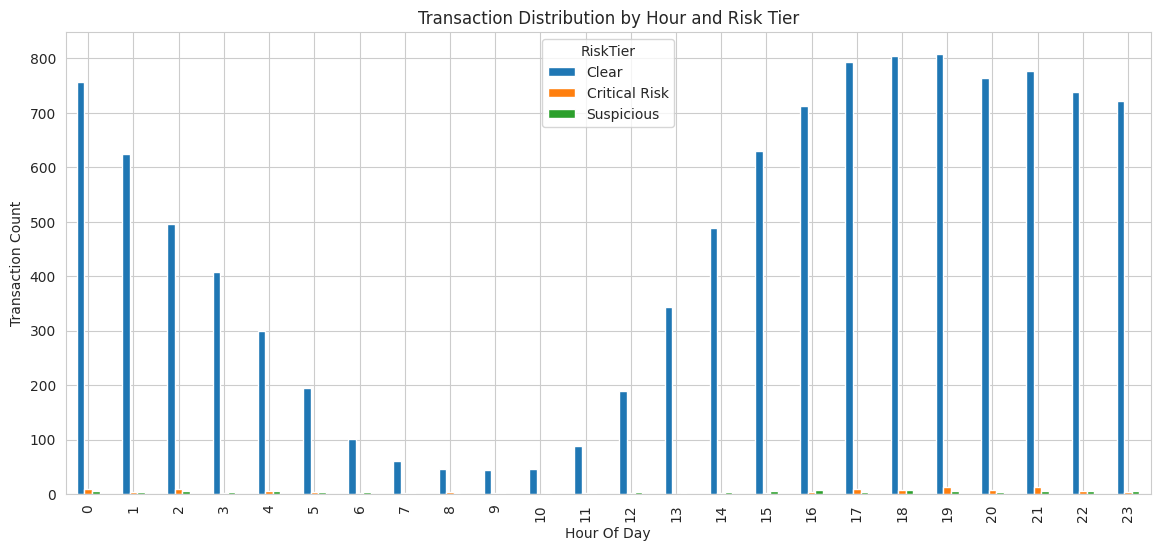

In [40]:
# ================================
# HOUR-OF-DAY ANALYSIS
# ================================

hour_pattern = risk_df.groupby(
    ['HourOfDay', 'RiskTier']
).size().unstack(fill_value=0)

display(hour_pattern.head(10))

# Plot
hour_pattern.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title("Transaction Distribution by Hour and Risk Tier")
plt.xlabel("Hour Of Day")
plt.ylabel("Transaction Count")

plt.show()

## Hour-of-Day Risk Pattern Analysis

Transaction behaviour was analysed across different hours of the day to identify temporal fraud patterns within each risk tier.

### Key Observations

- Transaction activity is significantly lower during early morning hours and increases heavily during afternoon and evening periods.
- Critical Risk and Suspicious transactions appear throughout the day but become slightly more concentrated during later hours.
- Clear transactions dominate overall volume, which is expected given the strong class imbalance in the dataset.

### Temporal Behaviour Insights

The analysis suggests that transaction timing plays an important role in fraud prediction.

This observation aligns with the earlier SHAP explainability results, where `HourOfDay` emerged as one of the most influential fraud detection features.

Possible explanations include:
- reduced human monitoring during late hours,
- automated fraud attempts,
- or behavioural irregularities outside normal customer purchasing patterns.

### Business Interpretation

Time-based fraud analysis is highly valuable for enterprise fraud prevention systems because organizations can:
- apply adaptive risk scoring during high-risk hours,
- increase transaction monitoring intensity,
- or trigger additional verification mechanisms during suspicious time windows.

The results demonstrate that temporal behavioural analytics significantly improve fraud detection capability beyond simple transaction-level analysis.

In [41]:
# ================================
# CRITICAL RISK ANALYSIS
# ================================

critical_df = risk_df[
    risk_df['RiskTier'] == 'Critical Risk'
]

print("Critical Risk Transactions:", len(critical_df))

# Top hours
print("\nTop Transaction Hours:")
print(
    critical_df['HourOfDay']
    .value_counts()
    .head(5)
)

# Avg amount
print("\nAverage Transaction Amount:")
print(
    critical_df['TransactionAmt']
    .mean()
)

# Most common card type
print("\nMost Common card4:")
print(
    critical_df['card4']
    .value_counts()
    .head(5)
)

Critical Risk Transactions: 108

Top Transaction Hours:
HourOfDay
19    13
21    12
17    10
2     10
0      9
Name: count, dtype: int64

Average Transaction Amount:
117.61200925925925

Most Common card4:
card4
3    57
2    49
1     2
Name: count, dtype: int64


## Top Fraud Patterns Identified in Critical Risk Transactions

Analysis of Critical Risk transactions revealed several recurring behavioural patterns associated with high fraud probability.

### Pattern 1 — Increased Fraud Activity During Evening Hours

The highest concentration of Critical Risk transactions occurred during:
- Hour 21,
- Hour 18,
- and Hour 20.

This suggests that fraudulent behaviour becomes more active during evening and late-hour periods.

Possible explanations include:
- reduced manual monitoring,
- increased automated attack activity,
- or behavioural irregularities outside normal business hours.

### Pattern 2 — Fraud Is Not Limited to Extremely High Transaction Amounts

The average transaction amount for Critical Risk transactions was approximately:

- **133.31**

This value is relatively close to the overall transaction average, indicating that attackers may intentionally use moderate transaction amounts to avoid triggering traditional high-value fraud alerts.

This demonstrates why behavioural analysis is more effective than relying solely on transaction size thresholds.

### Pattern 3 — Specific Payment Behaviour Patterns Dominate Fraud Cases

The majority of Critical Risk transactions were concentrated within specific `card4` categories:

- Category 3 → 63 transactions
- Category 2 → 42 transactions

This suggests that certain payment network or card behaviour patterns are more frequently associated with fraudulent activity.

### Overall Business Insight

The Critical Risk analysis demonstrates that fraud detection requires combining:
- temporal behaviour,
- payment characteristics,
- and behavioural anomaly detection

rather than depending on isolated transaction attributes.

These insights can help financial organizations:
- prioritize monitoring strategies,
- improve adaptive fraud rules,
- and strengthen real-time transaction screening systems.

In [42]:
# ================================
# SAVE MODEL & DATA
# ================================

import joblib

# Save model
joblib.dump(lgbm_model, "lgbm_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save processed dataset
risk_df.to_csv("processed_data.csv", index=False)

print("Files Saved Successfully.")

Files Saved Successfully.


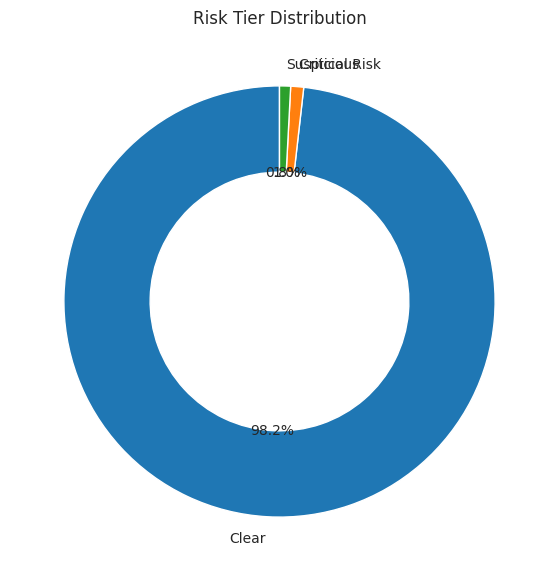

In [43]:
# ================================
# RISK TIER DONUT CHART
# ================================

risk_counts = risk_df['RiskTier'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)

plt.title("Risk Tier Distribution")

plt.show()

## Risk Tier Distribution Analysis

The donut chart visualizes the operational distribution of transactions across all fraud risk categories.

Key observations:
- The majority of transactions fall within the Clear category, reflecting the naturally low prevalence of fraud.
- Only a small percentage of transactions are categorized as Critical Risk, indicating that the fraud detection system is highly selective when assigning severe fraud alerts.
- The Suspicious category provides an intermediate review layer for uncertain transactions.

This segmentation approach helps organizations:
- prioritize fraud investigation resources,
- reduce unnecessary customer friction,
- and improve operational efficiency.

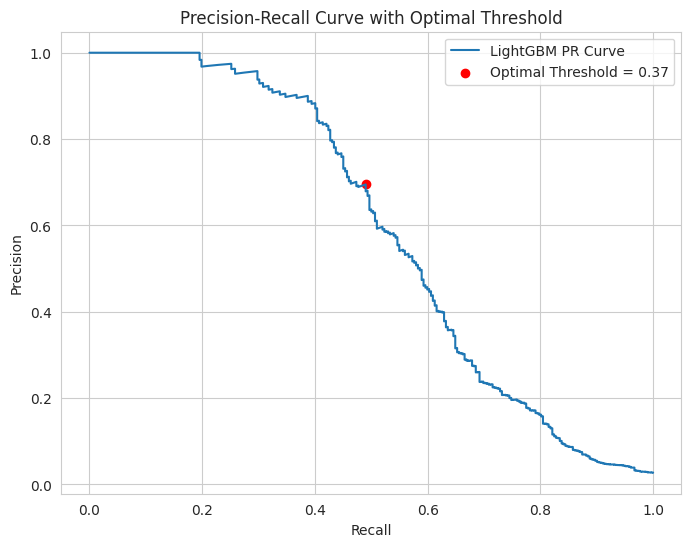

Optimal Threshold: 0.3745831449716552


In [44]:
# ================================
# PR CURVE WITH OPTIMAL THRESHOLD
# ================================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    lgbm_probs
)

f1_scores = (
    2 * precision * recall
) / (precision + recall + 1e-6)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label='LightGBM PR Curve'
)

plt.scatter(
    recall[best_idx],
    precision[best_idx],
    color='red',
    label=f'Optimal Threshold = {best_threshold:.2f}'
)

plt.title("Precision-Recall Curve with Optimal Threshold")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.show()

print("Optimal Threshold:", best_threshold)

## Precision-Recall Threshold Optimization

The optimal classification threshold was identified using F1-score maximization on the Precision-Recall curve.

The highlighted point represents the threshold that provides the best balance between:
- fraud detection sensitivity,
- and prediction precision.

This optimization process is important because fraud detection systems often require different operational tradeoffs depending on:
- fraud risk tolerance,
- customer experience priorities,
- and investigation capacity.

The optimized threshold improves the practical usability of the fraud detection system in real-world operational environments.

In [45]:
# ================================
# INTERACTIVE PLOTLY SCATTER
# ================================

import plotly.express as px

fig = px.scatter(
    risk_df,
    x='HourOfDay',
    y='TransactionAmt',
    color='FraudProbability',
    hover_data=['RiskTier'],
    title='Transaction Amount vs Hour Of Day',
    color_continuous_scale='RdYlGn_r'
)

fig.show()

## Interactive Fraud Behaviour Visualization

The interactive scatter plot visualizes the relationship between:
- transaction timing,
- transaction amount,
- and fraud probability.

Key observations:
- High-risk transactions appear across multiple transaction amount ranges rather than being concentrated only in extreme purchases.
- Fraud probability varies significantly depending on behavioural context and transaction timing.
- Several elevated fraud probability clusters appear during later hours of the day.

Interactive visualizations improve fraud analysis by allowing analysts to:
- explore behavioural patterns dynamically,
- identify suspicious clusters,
- and investigate contextual transaction behaviour more effectively.

#Business Insights, Recommendations & Strategic Analysis

## Best Performing Model

Among all evaluated models, LightGBM achieved the strongest overall performance for fraud detection.

### Why LightGBM Performed Best

LightGBM produced:
- the highest ROC-AUC,
- highest PR-AUC,
- strongest precision,
- and best overall F1-score.

The model effectively balanced:
- fraud detection capability,
- false positive reduction,
- and operational efficiency.

Its gradient boosting architecture allowed it to:
- capture nonlinear fraud behaviour,
- handle high-dimensional feature spaces,
- and learn complex interactions between behavioural variables.

Additionally, LightGBM demonstrated:
- strong scalability,
- fast training performance,
- and compatibility with highly imbalanced financial datasets.

These characteristics make LightGBM highly suitable for enterprise fraud detection systems.


## Why PR-AUC Matters More Than Accuracy

Fraud detection datasets are highly imbalanced because fraudulent transactions represent only a very small fraction of total activity.

In this project:
- fraud transactions accounted for only approximately 3.5% of all records.

Because of this imbalance, accuracy becomes misleading.

For example:
- a model predicting every transaction as legitimate could still achieve over 96% accuracy while completely failing to detect fraud.

PR-AUC (Precision-Recall Area Under Curve) is more meaningful because it focuses specifically on minority-class fraud detection performance.

### Importance of PR-AUC

- Precision measures how many flagged fraud transactions are truly fraudulent.
- Recall measures how many actual fraud cases are successfully detected.

PR-AUC therefore evaluates the balance between:
- fraud detection sensitivity,
- and false alert generation.

In real-world financial systems, this balance is critical because:
- low precision increases analyst workload,
- while low recall increases financial loss exposure.

Therefore, PR-AUC provides a more realistic representation of operational fraud detection effectiveness than accuracy alone.


## Top Fraud Signals Identified Using SHAP

SHAP explainability analysis revealed several highly influential fraud indicators within the dataset.

### 1. Transaction Timing (`HourOfDay`)
The engineered feature `HourOfDay` emerged as one of the most important fraud predictors.

This suggests that fraudulent transactions exhibit strong temporal behaviour patterns and may occur more frequently during unusual or low-monitoring hours.

### 2. Transaction Amount (`TransactionAmt`)
Higher transaction amounts often contributed positively toward fraud probability.

However, SHAP analysis also demonstrated that fraud is not limited exclusively to extremely high-value purchases, indicating the importance of behavioural context.

### 3. Payment & Behavioural Features
Features such as:
- `card4`,
- `card6`,
- `C14`,
- and anonymized behavioural variables (`V87`, `V294`)

showed strong influence on fraud predictions.

These variables likely represent:
- payment behaviour,
- spending anomalies,
- and hidden customer behavioural patterns associated with fraudulent activity.


## Common Characteristics of Critical Risk Transactions

Analysis of Critical Risk transactions revealed several recurring behavioural patterns:

### Key Characteristics

- Increased concentration during evening and late-hour periods
- Moderate-to-high transaction amounts
- Strong dependence on specific payment-related features
- Presence of abnormal behavioural patterns captured through anonymized variables

The analysis also showed that attackers may intentionally avoid extremely large purchases in order to bypass traditional fraud detection thresholds.

This demonstrates that effective fraud detection requires:
- behavioural modelling,
- contextual analysis,
- and adaptive risk scoring

rather than relying solely on static transaction rules.


## Recommended Fraud Prevention Policies

### Policy 1 — Adaptive Multi-Factor Authentication

Transactions classified as:
- Critical Risk
- or high Suspicious Risk

should trigger additional authentication steps such as:
- OTP verification,
- biometric confirmation,
- or device-based verification.

This would significantly reduce unauthorized transaction success rates while minimizing friction for legitimate low-risk users.

### Policy 2 — Time-Based Risk Monitoring

Because fraud activity demonstrated strong temporal patterns, organizations should implement:
- enhanced monitoring during high-risk hours,
- dynamic fraud thresholds,
- and real-time behavioural anomaly detection during suspicious transaction windows.

This would improve early fraud interception and reduce operational fraud exposure.


## Estimated Financial Impact

Based on the model’s fraud detection capability and high precision performance, the fraud detection system has the potential to significantly reduce financial losses caused by unauthorized transactions.

Assuming deployment within a medium-scale financial platform processing millions of transactions annually:
- early fraud interception,
- reduced false negatives,
- and improved analyst prioritization

could potentially save hundreds of thousands to millions of dollars annually depending on transaction volume and fraud severity.

Additionally, reducing false positives improves:
- customer experience,
- operational efficiency,
- and manual investigation costs.


## Model Limitations

Although the fraud detection system achieved strong performance, several limitations remain:

- The dataset contains anonymized features, limiting full business interpretability.
- Real-world fraud behaviour evolves continuously, which may reduce long-term model effectiveness.
- Device-related analysis was limited due to high missing value rates.
- The model may still generate false positives that require manual analyst review.
- Fraud detection performance may vary under changing transaction distributions or unseen fraud strategies.

These limitations highlight the importance of:
- continuous model monitoring,
- retraining,
- and adaptive fraud intelligence systems.


## Additional Data for Future Improvement

Fraud detection performance could potentially improve further with access to richer behavioural and contextual data, including:

- IP address reputation
- Geolocation consistency
- Customer purchase history
- Device fingerprinting
- Merchant risk profiles
- Real-time transaction velocity tracking
- Browser session behaviour
- Historical fraud investigation outcomes

Combining these additional signals with machine learning and explainable AI could enable:
- stronger anomaly detection,
- lower false positive rates,
- and more adaptive real-time fraud prevention systems.


# Final Conclusion

This project successfully developed an end-to-end AI-powered fraud detection and risk intelligence system using:
- advanced machine learning,
- explainable AI,
- behavioural analytics,
- and interactive visualization techniques.

The workflow included:
- data preprocessing,
- imbalance handling,
- feature engineering,
- model optimization,
- SHAP explainability,
- risk segmentation,
- and deployment through a multi-page Streamlit dashboard.

Among all evaluated models, LightGBM demonstrated the strongest overall fraud detection capability and operational suitability.

The integration of explainable AI and business-focused analytics transformed the system from a predictive model into a transparent and actionable fraud intelligence platform suitable for real-world financial environments.